# bestPitch+: was this the right pitch idea?

`docs/purpose.md`'s last stage, after Stuff+, Location+, and Pitching+:

> Identify, given pitch arsenal, best pitch/general location to throw it in
> (allowing for "zone," not a pinpoint). Given pitcher arsenal (using avg.
> Stuff+ and Location+ from spot), calculate hypothetical Pitching+ score
> (bestPitch). Identify if pitch "idea" was good (right pitch type/location).
> `bestPitch - Pitching+ = bestPitch+`

This is a *decision-quality* metric, not another "stuff" or "command" metric:
for a pitch actually thrown, would a different pitch type or a different zone
-- still something this exact pitcher can actually throw -- have scored
better in this exact situation?

This notebook builds and inspects `pitching_plus/bestpitch.py`'s answer: hold
the real game situation fixed (count, outs, base state, handedness) and
search every (candidate pitch type from the pitcher's own **reliable**
arsenal that season) x (candidate **zone**, Statcast's real 1-9 in-zone codes
plus the 4 chase/waste corners 11-14) combination. Each candidate's location
quality is `location.py`'s cached model prediction **averaged over a small
"target" area** around that zone's reference point (not a single pinpoint
query) -- combined with that pitcher's own real `stuff_plus` for the
candidate type, run through `pitching.py`'s *already-fitted* blend and its
pitch-level 100+ calibration (`_score_pitching_plus`, `level="pitch"`) so
"best" and "actual" land on the identical scale. The actual pitch's own
(type, zone) combination is scored the same target-averaged way before
comparing, so both sides of the comparison are the same kind of quantity.
The max across all candidates is `best_pitching_plus`.

Nothing here is reimplemented from scratch -- `add_stuff_plus`/
`add_location_plus`/`add_pitching_plus` are called as-is, and the
counterfactual search reuses `location.py`'s cached per-pitch-type models
(`load_cached_models`) and `pitching.py`'s fitted blend/calibration directly.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pitching_plus").is_dir():
            return candidate
    raise RuntimeError("Could not locate repo root (expected a 'pitching_plus' directory in a parent).")


REPO_ROOT = find_repo_root(Path.cwd())
SCRIPTS_DIR = REPO_ROOT / "pitching_plus" / "scripts"
DATA_PATH = REPO_ROOT / "data" / "MLB_2021-2025.csv"

sys.path.insert(0, str(SCRIPTS_DIR))

import stuff as stuff_mod
import location as location_mod
import pitching as pitching_mod
import bestpitch as bestpitch_mod
from stuff import PITCHER_COL, PITCH_TYPE_COL, SEASON_COL, PLAYER_NAME_COL, MIN_PITCHES_FOR_SCORE
from location import MIN_PITCHES_FOR_SEASON_SCORE
from pitching import add_pitching_plus
from bestpitch import add_bestpitch_plus, CANDIDATE_ZONE_CODES, TARGET_RADIUS_FT, ZONE_COL

In [2]:
COLOR_MAIN = "#1baf7a"
COLOR_NEG = "#c94f4f"
COLOR_GRID = "#e1e0d9"
COLOR_AXIS = "#c3c2b7"
COLOR_TEXT = "#0b0b0b"
COLOR_MUTED = "#898781"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": COLOR_AXIS,
    "axes.labelcolor": COLOR_TEXT,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": COLOR_GRID,
    "grid.linewidth": 0.8,
    "text.color": COLOR_TEXT,
    "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Score the full pipeline

`add_stuff_plus` -> `add_location_plus` -> `add_pitching_plus` -> `add_bestpitch_plus`,
exactly as `full_pipeline.py` runs it. `add_location_plus`/`add_bestpitch_plus`
use the cached models under `pitching_plus/models/` rather than retraining.

`add_bestpitch_plus`'s counterfactual search is the expensive step (minutes on the
full dataset, dwarfing stuff/location/pitching), so it's timed separately below and
called with `verbose=True`: it prints one line per (pitch type, zone) candidate --
elapsed time, candidates completed, and what fraction of in-scope rows have a
`best_pitching_plus` value so far -- instead of a single silent wait.

In [3]:
t0 = time.time()
raw_df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(raw_df):,} raw pitches in {time.time() - t0:.0f}s")

t0 = time.time()
df = stuff_mod.add_stuff_plus(raw_df)
df = location_mod.add_location_plus(df)
df = add_pitching_plus(df)
print(f"Scored stuff+location+pitching in {time.time() - t0:.0f}s")

t0 = time.time()
df = add_bestpitch_plus(df, verbose=True)
print(f"Scored bestPitch+ (counterfactual search) in {time.time() - t0:.0f}s")

in_scope = df.dropna(subset=["pitch_bestpitch_plus"]).copy()
print(f"{len(in_scope):,} / {len(df):,} pitches have a bestPitch+ score")

Loaded 3,565,743 raw pitches in 54s
Scored stuff+location+pitching in 80s
bestPitch+: 3,540,365 in-scope rows, 10 pitch-type models, 13 candidate zones (130 candidates in the search)
bestPitch+: counterfactual search (best_pitching_plus) ...
  [search 1/130] pitch_type=CH zone=1 -- 2,467,879/3,540,365 rows covered (70%) -- 27s elapsed
  [search 2/130] pitch_type=CH zone=2 -- 2,467,879/3,540,365 rows covered (70%) -- 28s elapsed
  [search 3/130] pitch_type=CH zone=3 -- 2,467,879/3,540,365 rows covered (70%) -- 29s elapsed
  [search 4/130] pitch_type=CH zone=4 -- 2,467,879/3,540,365 rows covered (70%) -- 30s elapsed
  [search 5/130] pitch_type=CH zone=5 -- 2,467,879/3,540,365 rows covered (70%) -- 31s elapsed
  [search 6/130] pitch_type=CH zone=6 -- 2,467,879/3,540,365 rows covered (70%) -- 32s elapsed
  [search 7/130] pitch_type=CH zone=7 -- 2,467,879/3,540,365 rows covered (70%) -- 33s elapsed
  [search 8/130] pitch_type=CH zone=8 -- 2,467,879/3,540,365 rows covered (70%) -- 34s elapse

## Sanity check: the zone reference grid

Each candidate zone is represented by the dataset-wide average `(plate_x,
plate_z_rel)` of every in-scope pitch actually thrown into it -- not an
invented grid. 13 rows are expected: Statcast's 9 in-zone codes plus the 4
chase/waste corners (11-14), covering real "up-and-in chase" type locations,
not just heart-of-the-zone spots. Printing it confirms the 1-9 block still
looks like a sensible 3x3 in-zone layout (top row = high, left column =
glove-side from the mound's perspective) and that 11-14 sit outside it, as
expected for chase locations.

In [4]:
location_required = location_mod.REQUIRED_COLS + location_mod.BASE_STATE_COLS + [ZONE_COL]
zone_in_scope = (
    df.loc[~df[PITCH_TYPE_COL].isin(stuff_mod.JUNK_PITCH_TYPES), location_required]
    .dropna(subset=location_mod.REQUIRED_COLS)
)
zone_engineered = location_mod._build_features(zone_in_scope)
zone_engineered[ZONE_COL] = zone_in_scope[ZONE_COL]

zone_ref = bestpitch_mod._zone_reference(zone_engineered)
print(zone_ref.round(3).to_string())

      plate_x  plate_z_rel
zone                      
1.0    -0.531        0.858
2.0    -0.003        0.858
3.0     0.525        0.855
4.0    -0.531        0.498
5.0     0.000        0.496
6.0     0.532        0.494
7.0    -0.528        0.140
8.0     0.003        0.137
9.0     0.535        0.136
11.0   -0.965        1.075
12.0    0.903        1.042
13.0   -0.894       -0.117
14.0    0.986       -0.177


## Checking the sign of bestPitch+

`best_pitching_plus` is a maximum over real candidate (pitch type, zone)
combinations from the pitcher's own reliable arsenal, and the pitch actually
thrown is always one of those candidates -- scored the identical
target-averaged way as every other candidate (see `_actual_smoothed_pitching_plus`
in bestpitch.py), not by its own pinpoint location. Because of that, the max
of the set should meet or exceed that one member almost always, so
`pitch_bestpitch_plus` should be positive or close to 0 for nearly every
pitch. Confirming that directly.

(Earlier versions of this notebook found a much larger, less trustworthy gap
here -- the candidate search was inflated by scoring a single pinpoint per
zone instead of averaging over an area, and by comparing that smoothed
`best_pitching_plus` against the *un*-smoothed, pinpoint `pitch_pitching_plus`.
Both are fixed as of this version; see docs/dev_log.md's 8/30 entry for the
full investigation.)

pitch_bestpitch_plus >= 0 for 100.0% of in-scope pitches
count    3535604.00
mean          10.84
std            8.16
min            0.00
25%            5.77
50%            9.47
75%           13.76
max           89.44


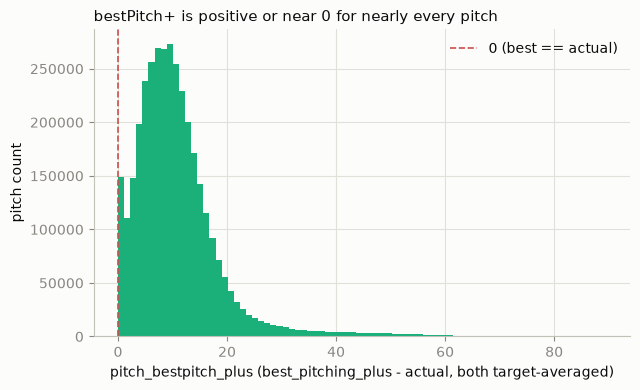

In [5]:
pct_non_negative = (in_scope["pitch_bestpitch_plus"] >= 0).mean()
print(f"pitch_bestpitch_plus >= 0 for {pct_non_negative:.1%} of in-scope pitches")
print(in_scope["pitch_bestpitch_plus"].describe().round(2).to_string())

fig, ax = plt.subplots(figsize=(6.5, 4))
values = in_scope["pitch_bestpitch_plus"].clip(-20, 100)
ax.hist(values, bins=80, color=COLOR_MAIN, edgecolor="none")
ax.axvline(0, color=COLOR_NEG, linewidth=1.2, linestyle="--", label="0 (best == actual)")
ax.set_xlabel("pitch_bestpitch_plus (best_pitching_plus - actual, both target-averaged)")
ax.set_ylabel("pitch count")
ax.set_title("bestPitch+ is positive or near 0 for nearly every pitch", loc="left", fontsize=10.5, color=COLOR_TEXT)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Leaderboard: whose pitch selection is closest to optimal?

Aggregated to (pitcher, season) across the *whole arsenal* -- the same
reliability level and bar (`MIN_PITCHES_FOR_SEASON_SCORE`, currently 100) as
`location_plus`'s own "final" season score, for the same reason: a pitcher's
average decision quality off a handful of pitches is too easily dominated by
a small sample. The smallest average `pitch_bestpitch_plus` is the closest
reading on "usually threw close to the best available pitch/location" this
model can currently produce; the largest is the most apparent room for a
better pitch selection, execution noise aside.

In [6]:
season_agg = (
    in_scope.groupby([PITCHER_COL, SEASON_COL], observed=True)
    .agg(
        mean_bestpitch_plus=("pitch_bestpitch_plus", "mean"),
        n_pitches=("pitch_bestpitch_plus", "count"),
    )
    .reset_index()
)
names = in_scope[[PITCHER_COL, PLAYER_NAME_COL]].drop_duplicates()
season_agg = season_agg.merge(names, on=PITCHER_COL, how="left")

reliable_season = season_agg[season_agg["n_pitches"] >= MIN_PITCHES_FOR_SEASON_SCORE]
print(f"{len(reliable_season):,} reliable pitcher-seasons")

closest_to_optimal = reliable_season.sort_values("mean_bestpitch_plus").head(15)
print("\nClosest to optimal pitch selection (smallest average bestPitch+):")
print(closest_to_optimal[[PLAYER_NAME_COL, SEASON_COL, "n_pitches", "mean_bestpitch_plus"]].round(1).to_string(index=False))

most_room = reliable_season.sort_values("mean_bestpitch_plus", ascending=False).head(15)
print("\nMost apparent room for a better pitch selection (largest average bestPitch+):")
print(most_room[[PLAYER_NAME_COL, SEASON_COL, "n_pitches", "mean_bestpitch_plus"]].round(1).to_string(index=False))

3,592 reliable pitcher-seasons

Closest to optimal pitch selection (smallest average bestPitch+):
    player_name  game_year  n_pitches  mean_bestpitch_plus
  Quijada, José       2023        161                  5.3
Bleier, Richard       2021        685                  5.5
 Ingram, Kolton       2023        100                  5.5
  Rogers, Tyler       2025        978                  5.6
      Clay, Sam       2022        100                  5.8
 Gilbert, Tyler       2024        145                  5.8
     Rowen, Ben       2021        198                  5.8
Bleier, Richard       2023        456                  5.8
  Hudson, Bryan       2023        164                  5.9
 Guenther, Sean       2024        243                  5.9
 Sherriff, Ryan       2023        104                  5.9
   Strahm, Matt       2021        136                  6.0
   Junk, Janson       2023        110                  6.0
    McGee, Jake       2021        878                  6.0
  Ryu, Hyun Jin  

## Synopsis

`pitch_bestpitch_plus` is positive or close to 0 for nearly every pitch, and
the typical gap is small -- a handful of points on the 100+ scale, not the
large, noisy gap earlier versions of this analysis found. Two fixes got it
there (docs/dev_log.md's 8/30 entry has the full investigation):

1. **Location's contribution now uses a pitch-level-appropriate spread.**
   `pitching.py`'s blend originally z-scored location_run_value using the
   spread of (pitcher, pitch_type, season) *aggregate* values -- much
   narrower than a single pitch's natural spread, since an aggregate is a
   mean over many pitches. That inflated every pitch-level score's distance
   from 100, and taking a max over several such over-wide draws compounded
   it further. Fixed by giving pitch-level scoring its own sigma and its own
   100+ calibration, fit on the pitch-level distribution itself.
2. **Candidates are scored over a small "target" area, not a pinpoint.**
   Querying a single reference point per zone let the max-over-candidates
   search exploit any local spike in the fitted regression surface.
   Averaging over a 5-point sample within a few baseball-diameters
   meaningfully reduced that. Doing this made `best_pitching_plus` a
   *smoothed* quantity being compared against `pitch_pitching_plus`, an
   *unsmoothed* one -- so the real pitch's own actual location is now also
   scored the same target-averaged way before comparing, restoring the
   property that the actual (pitch type, zone) combination is genuinely one
   of the candidates the max is taken over.

Caveats still worth naming for anyone building on this next:

- **The reliable-arsenal gate is a hard cutoff.** A pitch type thrown too
  rarely to calibrate a Stuff+ read for it that season is never considered as
  a candidate, even if it might genuinely be the pitcher's best option. This
  likely biases `best_pitching_plus` slightly low for pitchers actively adding
  a new, promising-but-unproven pitch mid-season.
- **The target radius is a judgment call, not a derived quantity.** 3
  baseball-diameters was chosen as a plausible "not a pinpoint" scale and
  confirmed empirically to help (see dev_log.md), but it wasn't tuned against
  any external ground truth -- a notably smaller or larger radius would move
  the exact magnitude of bestPitch+, even if the qualitative picture (small,
  mostly non-negative gaps) likely holds either way.
- **No sequencing.** This treats every pitch as an independent decision. A
  pitch that's a worse standalone "idea" but sets up a better one next pitch
  (tunneling, disrupting timing) gets no credit here -- `pitching.ipynb`'s own
  pitch-sequencing test found real, if modest, sequencing effects worth
  revisiting if this becomes a coaching-facing tool rather than an exploratory
  one.

## Quick look: top 10 by average Potential+, SP vs RP

Just curious -- not a rigorous "best pitchers" ranking. For every pitcher with
>1,500 total pitches in `in_scope`, take the plain average (no weighting, no
season-by-season aggregation) of `pitch_stuff_plus`, `pitch_location_plus`,
`pitch_pitching_plus`, and `pitch_bestpitch_plus` across every pitch of theirs
in the dataset. `potential_plus` is just `pitching_plus + bestpitch_plus`
(actual quality + apparent room for a better pitch idea), sorted descending.
Split into starters and relievers using a pitches-per-appearance heuristic
(the raw data has no role column) -- see the code cell for the exact cutoff.

In [7]:
pitcher_synopsis = (
    in_scope.groupby(PITCHER_COL, observed=True)
    .agg(
        n_pitches=("pitch_bestpitch_plus", "count"),
        stuff_plus=("pitch_stuff_plus", "mean"),
        location_plus=("pitch_location_plus", "mean"),
        pitching_plus=("pitch_pitching_plus", "mean"),
        bestpitch_plus=("pitch_bestpitch_plus", "mean"),
    )
    .reset_index()
)
pitcher_synopsis["potential_plus"] = pitcher_synopsis["pitching_plus"] + pitcher_synopsis["bestpitch_plus"]
names = in_scope[[PITCHER_COL, PLAYER_NAME_COL]].drop_duplicates()
pitcher_synopsis = pitcher_synopsis.merge(names, on=PITCHER_COL, how="left")

# No SP/RP flag in the raw data, so approximate it: pitches per (pitcher, game)
# appearance, averaged across every appearance in the raw (not just in-scope)
# data. Starters cluster well above ~40 pitches/appearance, relievers well
# below -- a rough split, not an official role.
appearance_pitch_counts = raw_df.groupby([PITCHER_COL, "game_pk"]).size()
role_df = appearance_pitch_counts.groupby(PITCHER_COL).mean().reset_index(name="avg_pitches_per_appearance")
role_df["role"] = np.where(role_df["avg_pitches_per_appearance"] >= 40, "SP", "RP")
pitcher_synopsis = pitcher_synopsis.merge(role_df[[PITCHER_COL, "role"]], on=PITCHER_COL, how="left")

qualified = pitcher_synopsis[pitcher_synopsis["n_pitches"] > 1500]
print(f"{len(qualified):,} pitchers with >1,500 total pitches "
      f"({(qualified['role'] == 'SP').sum()} SP / {(qualified['role'] == 'RP').sum()} RP by the pitches/appearance heuristic)")

display_cols = [PLAYER_NAME_COL, "n_pitches", "stuff_plus", "location_plus", "pitching_plus", "bestpitch_plus", "potential_plus"]

for role_label in ["SP", "RP"]:
    top10 = qualified[qualified["role"] == role_label].sort_values("potential_plus", ascending=False).head(10)
    print(f"\nTop 10 {role_label} by average Potential+ (Pitching+ + bestPitch+):")
    print(top10[display_cols].round(1).to_string(index=False))

695 pitchers with >1,500 total pitches (345 SP / 350 RP by the pitches/appearance heuristic)

Top 10 SP by average Potential+ (Pitching+ + bestPitch+):
     player_name  n_pitches  stuff_plus  location_plus  pitching_plus  bestpitch_plus  potential_plus
    Skenes, Paul       5122       119.5          100.6          107.8            15.1           123.0
     May, Dustin       3746       119.4           99.3          106.9            14.8           121.7
 Cabrera, Edward       7485       116.0           99.4          106.0            14.7           120.7
      Boyle, Joe       2140       113.5           98.7          103.9            16.2           120.1
Alcantara, Sandy      11954       119.8          100.3          107.8            12.1           119.8
   Bradish, Kyle       5799       108.9          100.5          104.2            15.5           119.7
   Soriano, José       5190       115.4           98.9          105.4            14.1           119.5
Ashcraft, Graham       6461     